In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("loan.csv")

In [3]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [4]:
df.sample()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
784,Steven Williams,West Geoffrey,43970,804,23228,29,65.0,True


In [5]:
df.shape

(2000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [7]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [8]:
df=df.drop(["name","city"],axis=1)

In [9]:
df.sample()

,income,credit_score,loan_amount,years_employed,points,loan_approved
252,129693,483,8013,6,55.0,False


In [10]:
df.columns

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'],
      dtype='object')

In [11]:
df["loan_approved"]=df["loan_approved"].astype(int)

In [31]:
df['loan_approved'].value_counts()

loan_approved
0    1121
1     879
Name: count, dtype: int64

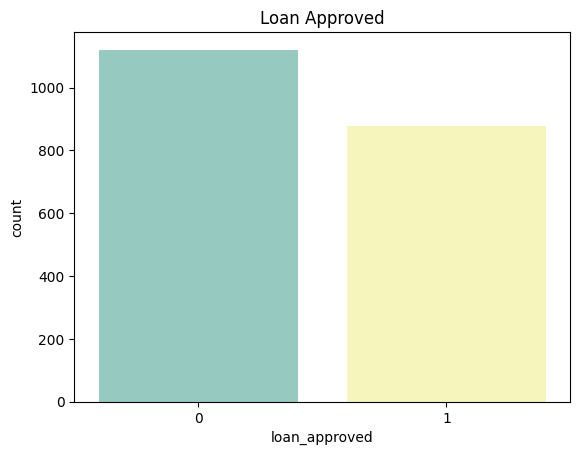

In [12]:
sns.countplot(data=df,x='loan_approved',palette='Set3')
plt.title("Loan Approved")
plt.show()

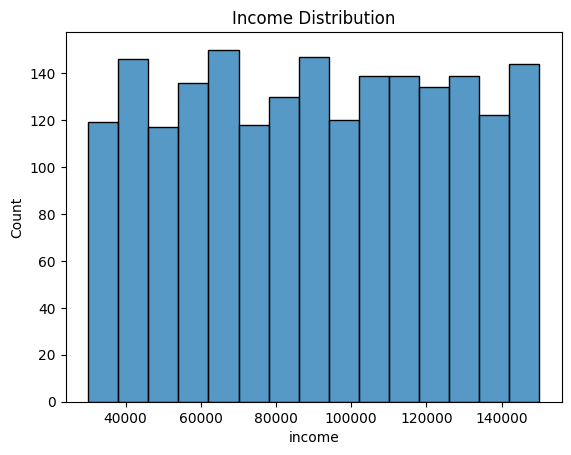

In [13]:
sns.histplot(data=df,x='income',bins=15)
plt.title('Income Distribution')
plt.show()

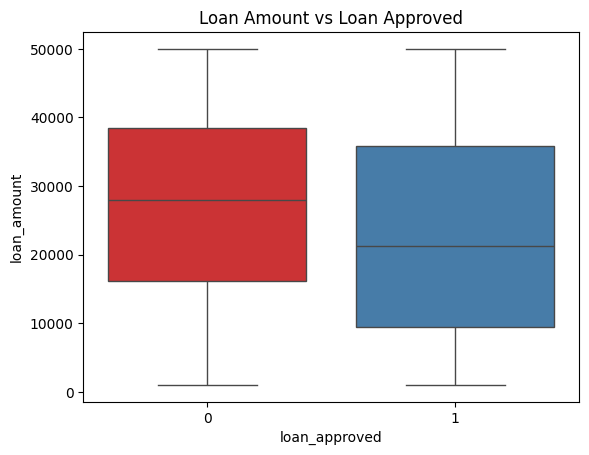

In [14]:
sns.boxplot(data=df,x='loan_approved',y='loan_amount',palette='Set1')
plt.title('Loan Amount vs Loan Approved')
plt.show()

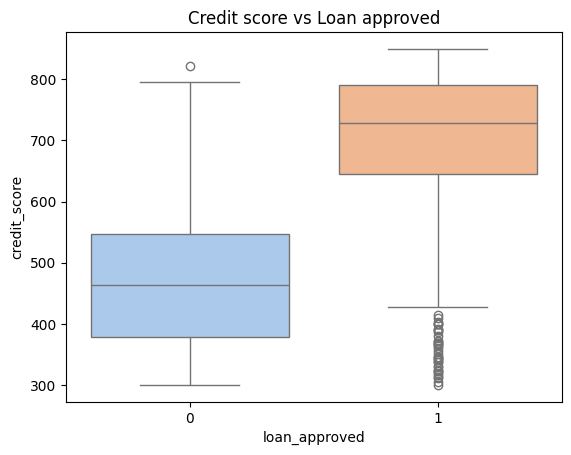

In [15]:
sns.boxplot(data=df,x='loan_approved',y='credit_score',palette='pastel')
plt.title('Credit score vs Loan approved')
plt.show()

<Axes: >

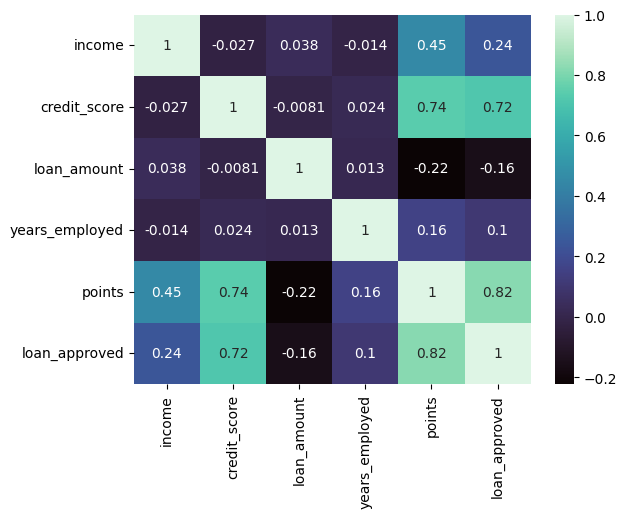

In [16]:
sns.heatmap(df.corr(),annot=True,cmap='mako')

In [17]:
X=df.drop(['loan_approved'],axis=1)
Y=df['loan_approved']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [21]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()

In [22]:
dt.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
rf.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
Y_pred_dt=dt.predict(X_test)
Y_pred_rf=rf.predict(X_test)

In [25]:
print('Decision Tree Accuracy Score:',accuracy_score(Y_test,Y_pred_dt))
print('Random Forest Accuracy Score:',accuracy_score(Y_test,Y_pred_rf))

Decision Tree Accuracy Score: 1.0
Random Forest Accuracy Score: 1.0


In [26]:
print(confusion_matrix(Y_test,Y_pred_rf))

[[217   0]
 [  0 183]]


In [27]:
print(classification_report(Y_test,Y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [28]:
print(dt.score(X_train,Y_train))
print(dt.score(X_test,Y_test))

1.0
1.0


In [29]:
rf.feature_importances_

array([0.04137037, 0.27692101, 0.01892072, 0.00897345, 0.65381445])

In [32]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))